# Propiedad del Mundo Pequeño en redes aleatorias

Recordemos que en una red aleatoria con $n$ nodos, probabilidad de enlace $p$ y grado promedio $\langle k\rangle$, la distribución de grados $p_k$ sigue una distribución binomial (y Poisson para $n$ suficientemente grande). Es decir, la mayoría de los nodos tienen grado $\langle k\rangle$.

Si consideramos un nodo arbitrario $n_0$, con seguridad podemos decir que desde $n_0$ hay:

- $\langle k\rangle$ nodos a distancia $d=1$,
- $\langle k\rangle^2$ nodos a distancia $d=2$,
- $\langle k\rangle^3$ nodos a distancia $d=3$,

En general,

- $\langle k\rangle^d$ nodos a distancia $d$ de $n_0$.

Sea $N(d)$ nodos a distancia $d$ de $n_0$. Entonces

$$N(d)=1+\langle k\rangle+\langle k\rangle^2+\ldots+\langle k\rangle^d=\frac{1-\langle k\rangle^{d+1}}{1-\langle k\rangle}$$

Por otro lado, si denotamos por $d_{\max}$ al diámetro de la red, entonces $$N(d_{\max})\approx n$$

Sustituyendo en la anterior igualdad,

$$N(d_{\max})=\frac{1-\langle k\rangle^{d_{\max}+1}}{1-\langle k\rangle}\approx n$$

Para redes muy grandes, el grado promedio es mucho mayor a 1, por lo que podemos despreciar al 1 en la expresión, por tanto,

$$n\approx\frac{1-\langle k\rangle^{d_{\max}+1}}{1-\langle k\rangle}\approx\frac{-\langle k\rangle^{d_{\max}+1}}{-\langle k\rangle}=\langle k\rangle^{d_{\max}}$$

Aplicando logaritmos, tenemos que la distancia máxima entre dos nodos está dada por

$$d_{\max}=\frac{\log(n)}{\log(\langle k\rangle)}$$

Es decir, la distancia máxima entre dos nodos de la red, es proporcional al logaritmo del tamaño de la red. A esto se le conoce como Propiedad del mundo Pequeño.

$\textbf{Actividad}:$ Investiga la población mundial y, usando logaritmo (base 10, por ejemplo), estima la distancia máxima en la red de la población mundial (Nota: no tiene que ser exacto).

La poblacion mundial se obtuvo de https://populationtoday.com/es/

In [198]:
import numpy as np

n = int(np.log(8_285_310_000))
k = 100
d_max = n/np.log(k)
print(d_max)

4.777239300935769


In [199]:
n

22

?!?!?!?!?! Se tiene que, si todos conocemos a 100 personas (en promedio) estamos a 4.77 personas de cualquier persona del mundo.

# Introducción al modelo de Watts-Strogatz

In [200]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

Comencemos con una red anillo con $n$ nodos en un ciclo y cada nodo está conectado con $c$ nodos más cercanos; es decir, $\frac{c}{2}$ vecinos a la izquierda y $\frac{c}{2}$ vecinos a la derecha. Definamos $l=\frac{c}{2}$.

Definamos la red anillo regular con $n$ nodos y $c=2l$ vecinos más cercanos.

In [201]:
def Anillo(n, l = 2):
    nodos = np.arange(n)
    G = nx.Graph()
    G.add_nodes_from( nodos )
    
    for i in range(l):
        G.add_edges_from( zip( nodos, np.roll(nodos, i+1) ) )
    return G

Cambia los parámetros de $n$ y $l$ para ver cómo se modifica el coeficiente (promedio) de clustering.

el coeficiente de clustering de la red es :  0.5


C:\Users\HERIBERTO\AppData\Local\Temp\ipykernel_27988\4129985775.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


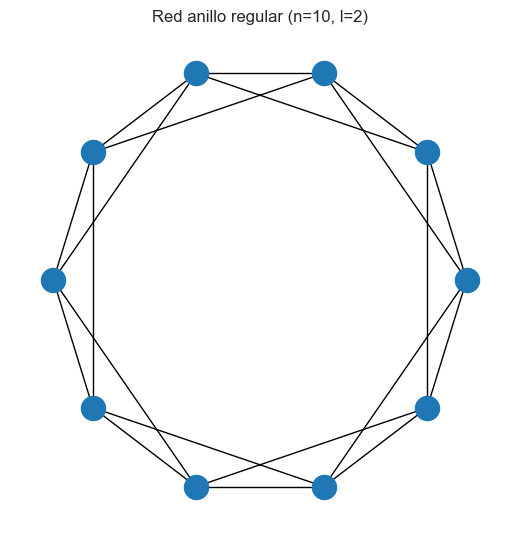

In [202]:
G = Anillo(10, 2) #
print('el coeficiente de clustering de la red es : ', nx.clustering(G)[0])
plt.figure(figsize = [5,5])
nx.draw_circular(G)
plt.title('Red anillo regular (n=10, l=2)')
plt.tight_layout()

También se puede ver cómo se modifica el diámetro de la red.

In [203]:
nx.diameter(G)

3

En el siguiente código, distinguimos al primer nodo que fue añadido a la red (con color rojo), para tenerlo como referencia cuando la red sea modificada. Cambia los parámetros y observa cómo se modifica el coeficiente de clustering y el diámetro.

C:\Users\HERIBERTO\AppData\Local\Temp\ipykernel_27988\401985387.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


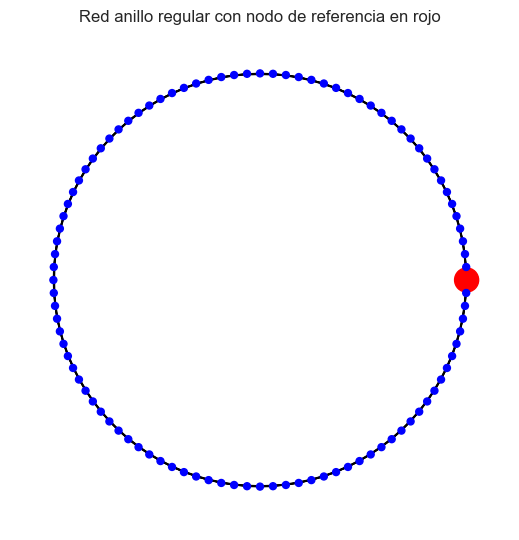

Clustering =  0.6
Diametro =  17


In [204]:
G = Anillo(100,3)

n = len(G)
tamanos = [300]
tamanos = tamanos + (n-1)*[25]
colores = ['red']
colores = colores + (n-1)*['blue']

plt.figure(figsize = [5,5])
nx.draw_circular(G, node_size = tamanos, node_color = colores)
plt.title('Red anillo regular con nodo de referencia en rojo')
plt.tight_layout()
plt.show()

print('Clustering = ', nx.average_clustering(G) ) 
print('Diametro = ', nx.diameter(G) ) 

$\textbf{Responde:}$

- ¿Se puede decir que la red generada tiene la propiedad del mundo pequeño?
	No, porque para $n=100$ y $l=3$ el diámetro es $17$, mucho mayor que la estimación logarítmica de una red de mundo pequeño como la que hicimos al principio.
- Si los nodos se conectan a más vecinos, ¿hay alguna relación enetre el diámetro de la red con el parámetro $l$?
	Sí. Al aumentar $l$, cada nodo se conecta con más vecinos y el diámetro disminuye; decrece (aprox.) de manera inversa a $l$.

In [205]:
round(50/3)

17

In [206]:
np.log(100)/np.log(6)

np.float64(2.570194417876938)

## Matriz de distancia

Podemos visualizar las distancias entre cada par de nodos. Generamos la matriz de distancias, una matriz cuadrada de $n\times n$ en donde la entrada $ij$ es la distancia geodésica entre los nodos $i$ y $j$. Usamos la función shortest_path_length de NetworkX.

In [207]:
MatD0 = np.zeros([n,n]) #Generamos una matriz de ceros
for i in range(n):
    for j in range(n):
        MatD0[i,j] = nx.shortest_path_length(G, i, j) #Agregamos la distancia entre los nodos i y j a la entrada ij
dmin = np.min(MatD0)
dmax = np.max(MatD0)

Podemos visualizar la matriz de distancias junto con la red. Colores cálidos (amarillo) representan parejas de nodos con distancia grande y colores fríos (azul) representan nodos con distancia pequeña, como lo muestra la barra vertical. Notemos que en la disagonal tenemos color negro (la distancia de un nodo con sus próximos vecinos (y sí mismo) es muy pequeña).

Cambia los parámetros de la red ($n$ y $l$) y observa cómo se modifican las distancias y el coeficiente de clustering.

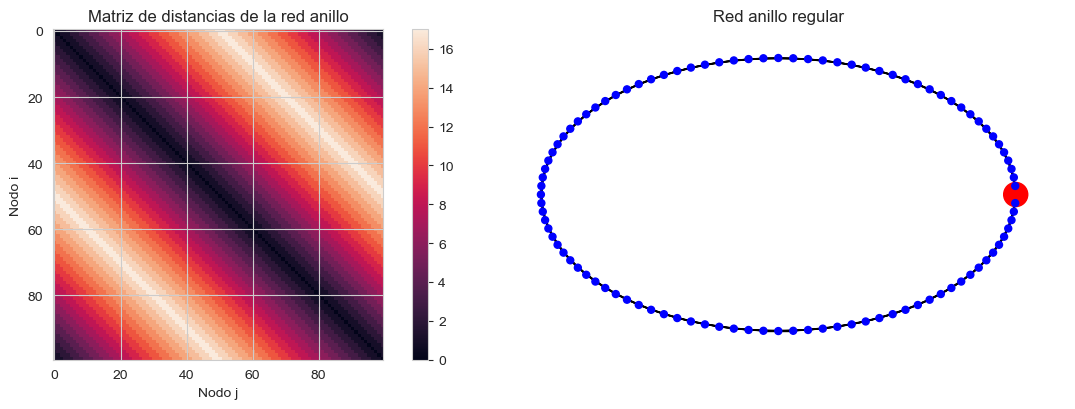

Distancia m?xima entre nodos (di?metro): 	 17.0
Distancia promedio entre nodos: 		 8.67
Coeficiente de clustering promedio de la red: 	 0.6


In [208]:
h = .6 #parametro para modificar el tama?o de la imagen
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize = (20*h,7*h)) 
nx.draw_circular(G, node_size = tamanos, node_color = colores, ax = ax2)


pos = ax1.imshow(MatD0, vmin=dmin, vmax=dmax)
fig.colorbar(pos, ax=ax1)

ax1.set_title('Matriz de distancias de la red anillo')
ax1.set_xlabel('Nodo j')
ax1.set_ylabel('Nodo i')

ax2.set_title('Red anillo regular')
plt.tight_layout()
plt.show()

print('Distancia m?xima entre nodos (di?metro): 	', np.max(MatD0))
print('Distancia promedio entre nodos: 		', np.mean(MatD0))
print('Coeficiente de clustering promedio de la red: 	', nx.average_clustering(G))

# Variante del Modelo

Recordemos que el Modelo de Watts-Strogatz nos dice que, una vez que tenemos una red anillo, elegimos una arista y con probabilidad $p$ la removemos y la reemplazamos con una arista que una a dos nodos elegidos de forma aleatoriamente uniforme. Estas nuevas aristas se llaman $\textbf{atajos}$, que nos permiten disminuir la distancia máxima (diámetro) de la red.

Comenzaremos analizando una variante del modelo. Vamos a seleccionar un nodo $n_1$ de forma aleatoria, seleccionamos un vecino de $n_1$, digamos $n_2$, también de forma aleatoria, quitamos la arista $(n_1,n_2)$, después, entre los nodos restantes de la red elegimos uno al azar, digamos $n_3$, y se agrega la arista $(n_1,n_3)$.

In [209]:
def cambio_enlace(G):
  # ojo con el uso de los conjutos (set)
  nodo1 = np.random.choice(G)
  nodo2 = np.random.choice( G[nodo1] )
  G.remove_edge(nodo1, nodo2)
  seleccion = set(G) - set(G[nodo1]) - set([nodo1])
  
  nuevo_nodo = np.random.choice( list(seleccion) )
  
  G.add_edge(nodo1, nuevo_nodo)

Para visualizar cómo cambió la red, generamos una copia de la red original:

- Genera una red anillo (puedes usar otros parámetros).
- Ejecuta la celda "Modificación de redes". Esta celda modifica la red paso a paso, puedes ejecutarla varias veces para ver cómo se va modificando la red.
- Puedes usar otros parámetros ejecutando nuevamente la celda "Genera las redes".

$\textbf{Responde}:$
 - Al modificar la red una vez, ¿se disminuye el diámetro? ¿Por qué?
 	Si se modifica una única vez, no disminuye el diámetro (creo). Puedes pensar que, si se crea un atajo a la derecha de un nodo, sin pérdida de generalidad, el diámetro queda igual a la izquierda; aunque conecte a las dos parejas más extremas, si agarras al nodo de en medio del atajo, su vecino más extremo va a seguir a la misma distancia que antes.

 - ¿Qué característica tienen los nuevos enlaces que disminuyen mucho la distancia promedio?
	Son atajos largos que conectan regiones lejanas de la red.

 - ¿Qué característica tienen los nuevos enlaces que casi no disminuyen la distancia promedio?
	Suelen unir nodos que ya estaban cerca o dentro de la misma vecindad local.
 
 - ¿El coeficiente de clustering puede disminuir a la mitad? ¿Cuántos pasos se necesitarían? Si es el caso, ¿qué pasó con la distancia promedio y el diámetro?
	Sí, pero hacen falta bastantes cambios. En corridas con $n=100$ y $l=3$ se necesitó de $70$ a $90$ pasos; para entonces la distancia promedio y el diámetro ya habían disminuido mucho (no sé por que ese tiempo).

In [210]:
# Genera las redes

n = 100
l = 3

G = Anillo(n, l)

G2 = G.copy()

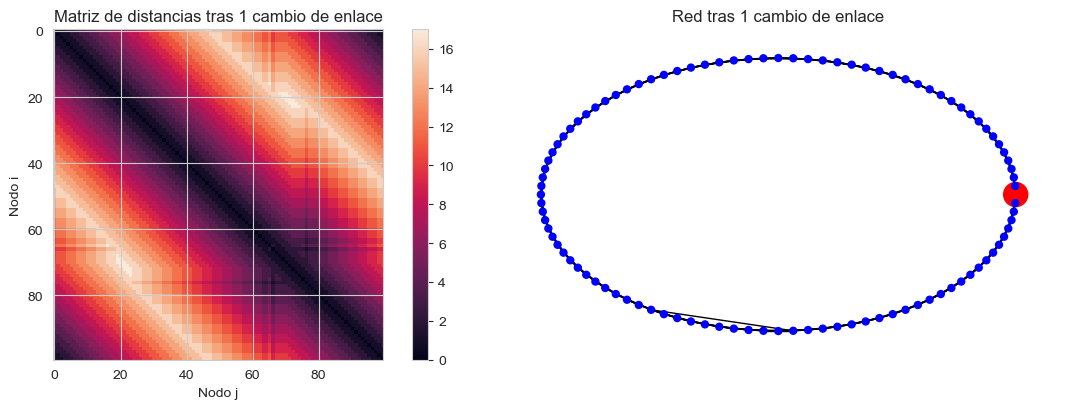

Diametro: 		 17.0 --> 17.0
Distancia media: 	 8.67 --> 8.2796
Clustering: 		 0.6 --> 0.591952380952381


In [211]:
# Modificaci?n de la red

cambio_enlace(G2)

MatD = np.zeros([n,n])
for i in range(n):
    for j in range(n):
        MatD[i,j] = nx.shortest_path_length(G2, i, j)

        
        
h = .6

fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize = (20*h,7*h)) 
nx.draw_circular(G2, node_size = tamanos, node_color = colores, ax = ax2)


#fig, ax = plt.subplots(figsize = (10*h,7*h)) 
pos = ax1.imshow(MatD, vmin=dmin, vmax=dmax)
fig.colorbar(pos, ax=ax1)
ax1.set_title('Matriz de distancias tras 1 cambio de enlace')
ax1.set_xlabel('Nodo j')
ax1.set_ylabel('Nodo i')

ax2.set_title('Red tras 1 cambio de enlace')

plt.tight_layout()
plt.show()
print('Diametro: 		', np.max(MatD0), '-->',np.max(MatD))
print('Distancia media: 	', np.mean(MatD0), '-->', np.mean(MatD))
print('Clustering: 		', nx.average_clustering(G), '-->', nx.average_clustering(G2))

Se puede generar un ciclo para hacer varios enlaces en un mismo paso.

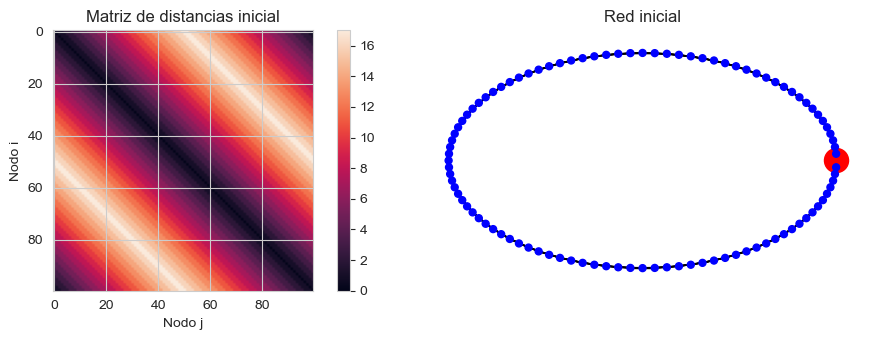

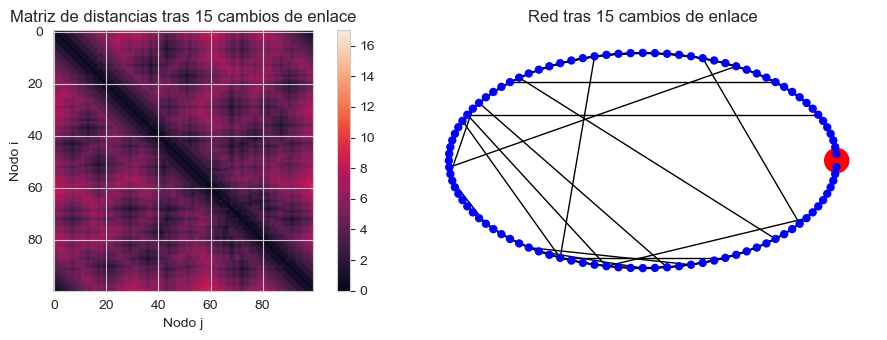

Diametro:  17.0 --> 9.0
Distancia media:  8.67 --> 4.1564
Clustering:  0.6 --> 0.5312380952380952


In [212]:
G2 = G.copy()

veces = 15

for k in range(veces):
    cambio_enlace(G2)


MatD = np.zeros([n,n])

for i in range(n):
    for j in range(n):
        MatD[i,j] = nx.shortest_path_length(G2, i, j)

        
        
h = .5

fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize = (20*h,7*h)) 
nx.draw_circular(G, node_size = tamanos, node_color = colores, ax = ax2)


#fig, ax = plt.subplots(figsize = (10*h,7*h)) 
pos = ax1.imshow(MatD0, vmin=dmin, vmax=dmax)
fig.colorbar(pos, ax=ax1)

ax1.set_title('Matriz de distancias inicial')
ax1.set_xlabel('Nodo j')
ax1.set_ylabel('Nodo i')

ax2.set_title('Red inicial')
plt.tight_layout()
plt.show()


fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize = (20*h,7*h)) 
nx.draw_circular(G2, node_size = tamanos, node_color = colores, ax = ax2)


#fig, ax = plt.subplots(figsize = (10*h,7*h)) 
pos = ax1.imshow(MatD, vmin=dmin, vmax=dmax)
fig.colorbar(pos, ax=ax1)
ax1.set_title(f'Matriz de distancias tras {veces} cambios de enlace')
ax1.set_xlabel('Nodo j')
ax1.set_ylabel('Nodo i')

ax2.set_title(f'Red tras {veces} cambios de enlace')

plt.tight_layout()
plt.show()
print('Diametro: ', np.max(MatD0), '-->',np.max(MatD))
print('Distancia media: ', np.mean(MatD0), '-->', np.mean(MatD))
print('Clustering: ', nx.average_clustering(G), '-->', nx.average_clustering(G2))

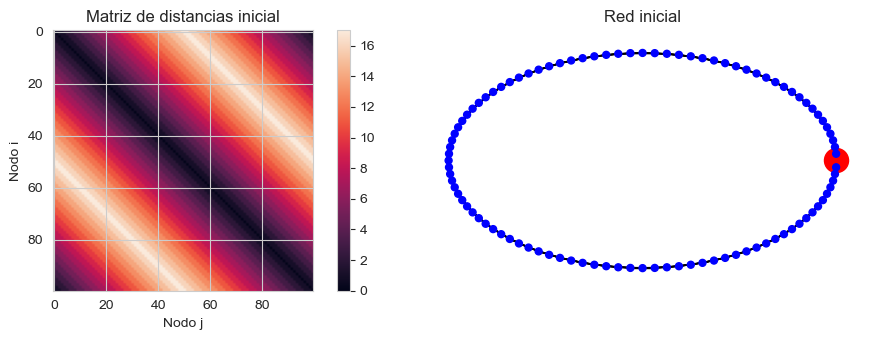

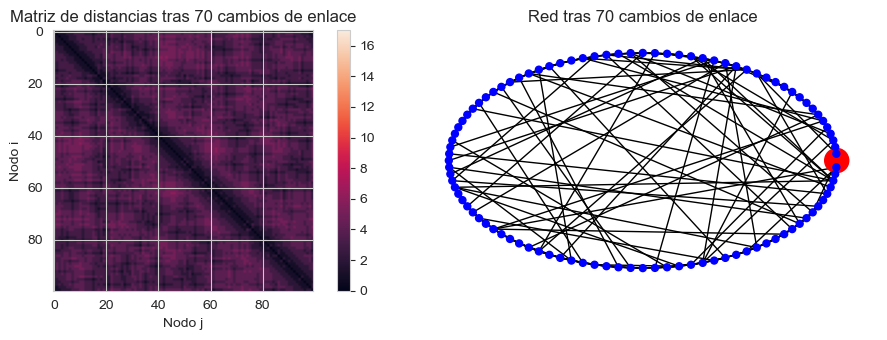

Diametro:  17.0 --> 6.0
Distancia media:  8.67 --> 3.1436
Clustering:  0.6 --> 0.3243492063492064


In [213]:
# Genera las redes

n = 100
l = 3

G = Anillo(n, l)

G2 = G.copy()

G2 = G.copy()

veces = 70

for k in range(veces):
    cambio_enlace(G2)


MatD = np.zeros([n,n])

for i in range(n):
    for j in range(n):
        MatD[i,j] = nx.shortest_path_length(G2, i, j)

        
        
h = .5

fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize = (20*h,7*h)) 
nx.draw_circular(G, node_size = tamanos, node_color = colores, ax = ax2)


#fig, ax = plt.subplots(figsize = (10*h,7*h)) 
pos = ax1.imshow(MatD0, vmin=dmin, vmax=dmax)
fig.colorbar(pos, ax=ax1)

ax1.set_title('Matriz de distancias inicial')
ax1.set_xlabel('Nodo j')
ax1.set_ylabel('Nodo i')

ax2.set_title('Red inicial')
plt.tight_layout()
plt.show()


fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize = (20*h,7*h)) 
nx.draw_circular(G2, node_size = tamanos, node_color = colores, ax = ax2)


#fig, ax = plt.subplots(figsize = (10*h,7*h)) 
pos = ax1.imshow(MatD, vmin=dmin, vmax=dmax)
fig.colorbar(pos, ax=ax1)
ax1.set_title(f'Matriz de distancias tras {veces} cambios de enlace')
ax1.set_xlabel('Nodo j')
ax1.set_ylabel('Nodo i')

ax2.set_title(f'Red tras {veces} cambios de enlace')

plt.tight_layout()
plt.show()
print('Diametro: ', np.max(MatD0), '-->',np.max(MatD))
print('Distancia media: ', np.mean(MatD0), '-->', np.mean(MatD))
print('Clustering: ', nx.average_clustering(G), '-->', nx.average_clustering(G2))

$\textbf{Actividad}:$ 

- Genera una red.
- Genera una lista para el diámetro, la distancia promedio y el coeficiente de clustering. EL primer elemento de la lista es el valor de la variable de la red inicial.
- Aplica la función cambio_enlace varias veces (define cuantas veces), y cada vez que lo apliques, calcula los nuevos valores y agrégalos a la lista usando lista.append(valor). Para ello haz un bucle usando k.
- Grafica las listas de valores generados. El diámetro y la distancia promedio se grafican juntas, el clustering aparte.

In [214]:
#Genera la red anillo
n = 100
l = 3

G = Anillo(n,l)

G2 = G.copy()

In [215]:
# Generar una lista para cada variable.

Diam = [nx.diameter(G2)]
Dist = [nx.average_shortest_path_length(G2)]
Clus = [nx.average_clustering(G2)]


In [216]:
# Aplica la fucnión cambio_enlace varias veces

k = 20 #numero de veces que se aplicará la función

for i in range(k):
    cambio_enlace(G2)
    Diam.append(nx.diameter(G2))
    Dist.append(nx.average_shortest_path_length(G2))
    Clus.append(nx.average_clustering(G2))

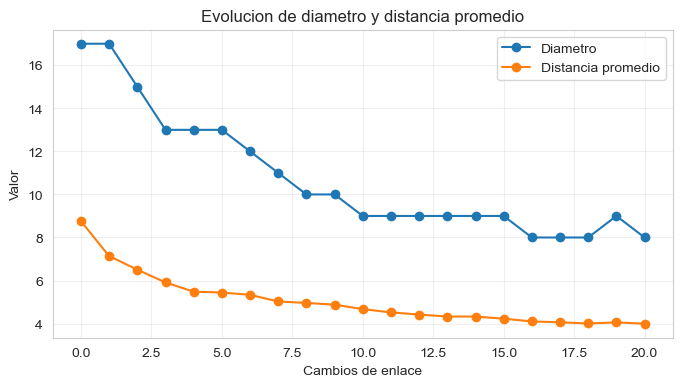

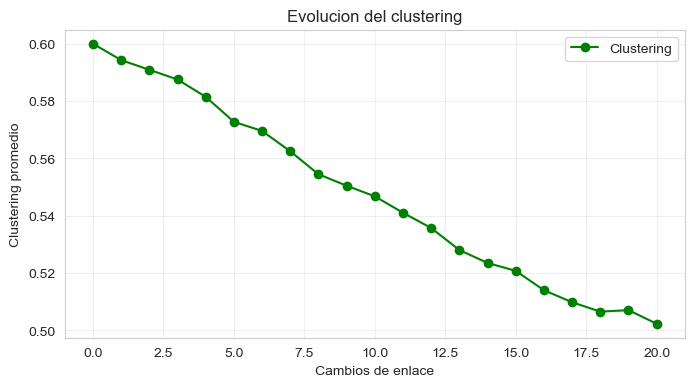

In [217]:
# Grafica
plt.figure(figsize = (8,4))
plt.plot(Diam, marker='o', label='Diametro')
plt.plot(Dist, marker='o', label='Distancia promedio')
plt.xlabel('Cambios de enlace')
plt.ylabel('Valor')
plt.title('Evolucion de diametro y distancia promedio')
plt.grid(alpha = 0.3)
plt.legend()
plt.show()

plt.figure(figsize = (8,4))
plt.plot(Clus, marker='o', color='green', label='Clustering')
plt.xlabel('Cambios de enlace')
plt.ylabel('Clustering promedio')
plt.title('Evolucion del clustering')
plt.grid(alpha = 0.3)
plt.legend()
plt.show()

$\textbf{Responde:}$

- ¿Qué se puede decir respecto al comportamiento de las distancias y el clustering?
	Ambos disminuyen conforme se hacen más cambios de enlace, pero no lo hacen al mismo ritmo.
- ¿Cómo decaen?
	Las distancias decaen rápido al principio y luego más lentamente, mientras que el clustering decae de forma más suave y gradual.
- ¿Cuál decae primero?
	La distancia promedio decae primero; el clustering tarda más en bajar.


$\textbf{Actividad}:$ Ejecuta varias veces la actividad anterior, guarda la información de cada ejecución y al final haz un promedio. Se sugieren no más de 15 ejecuciones.

In [218]:
# Se generan las listas donde se introducirán las listas de los valores de cada corrida.
n = 100
l = 3

G = Anillo(n,l)


DIAM = []
DIST = []
CLUS = []

ejecuciones = 10

for j in range(ejecuciones):
    #### Haz lo mismo que hiciste en la actividad anterior, pero ahora dentro de este bucle para que se haga varias veces
    G2 = G.copy()

    #crea las listas de cada variable aplicada a G2

    Diam = [nx.diameter(G2)]
    Dist = [nx.average_shortest_path_length(G2)]
    Clus = [nx.average_clustering(G2)]

    k = 20 # numero de cambio de enlaces
    for i in range(k):
      cambio_enlace(G2)
      Diam.append(nx.diameter(G2))
      Dist.append(nx.average_shortest_path_length(G2))
      Clus.append(nx.average_clustering(G2))

    #### 
    
    #las siguientes lineas agregan la información de cada ejecución a una lista
    DIAM.append(Diam)
    DIST.append(Dist)
    CLUS.append(Clus)

Hacemos el promedio de cada lista sobre todas las ejecuciones.

In [219]:
Y1 = np.mean(np.array(DIAM), axis = 0)
Y2 = np.mean(np.array(DIST), axis = 0)
Y3 = np.mean(np.array(CLUS), axis = 0)

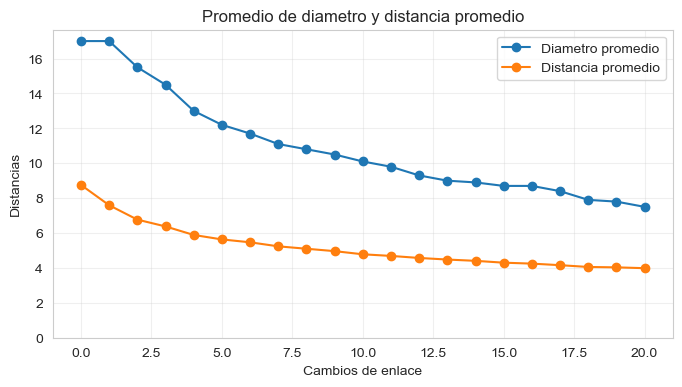

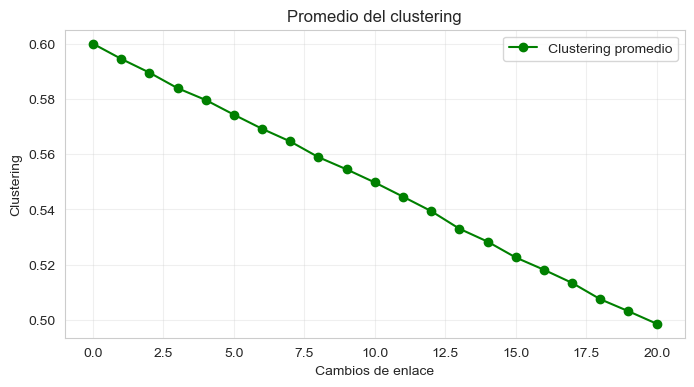

In [220]:
plt.figure(figsize = (8,4))
plt.plot(Y1, marker='o')
plt.plot(Y2, marker='o')
plt.ylim([0,None])
plt.xlabel('Cambios de enlace')
plt.ylabel('Distancias')
plt.title('Promedio de diametro y distancia promedio')
plt.legend(['Diametro promedio', 'Distancia promedio'])
plt.grid(alpha = 0.3)
plt.show()

plt.figure(figsize = (8,4))
plt.plot(Y3, marker='o', color='green', label='Clustering')
plt.xlabel('Cambios de enlace')
plt.ylabel('Clustering')
plt.title('Promedio del clustering')
plt.legend(['Clustering promedio'])
plt.grid(alpha = 0.3)
plt.show()

- ¿Puedes decir algo sobre el comportamiento de las distancias y el clustering? ¿Cómo decaen? ¿Cuál decae más rápido?
	Sí. En promedio ambas cantidades disminuyen conforme aumentan los cambios de enlace.
	La distancia promedio cae rápido al inicio y luego más lentamente, mientras que el clustering desciende de forma más gradual.
	La distancia promedio es la que decae más rápido.
	Por ejemplo, después de 20 cambios el diámetro promedio pasó de 17 a aproximadamente 8.2, la distancia promedio de 8.76 a aproximadamente 4.02 y el clustering solo de 0.60 a aproximadamente 0.50.

# El Modelo de Newman-Watts-Strogatz


La funcion que reubica una arista con probabilidad $p$ corresponde al modelo original de Watts-Strogatz. En la variante Newman-Watts-Strogatz, en lugar de eliminar una arista local, se conserva el anillo y se agregan atajos con probabilidad $p$. En esta seccion trabajaremos con esa segunda version, permite comparar que pasa cuando aparecen atajos sin destruir la estructura local de la red.

In [221]:
def re_enlazar_ws(G, p):
    nodos = set(G)
    
    for enlace in list(G.edges()):
        if np.random.rand() < p:
            u, v = enlace
            eleccion = nodos - {u} - set(G[u])
            if len(eleccion) == 0:
                continue
            nuevo_v = np.random.choice(list(eleccion))
            G.remove_edge(u, v)
            G.add_edge(u, nuevo_v)


def agregar_atajo(G):
    nodo1 = np.random.choice(list(G.nodes()))
    eleccion = set(G) - set(G[nodo1]) - {nodo1}
    if len(eleccion) == 0:
        return
    nuevo_nodo = np.random.choice(list(eleccion))
    G.add_edge(nodo1, nuevo_nodo)


def agregar_atajos(G, p):
    nodos = set(G)
    aristas_originales = list(G.edges())
    
    for u, v in aristas_originales:
        if np.random.rand() < p:
            eleccion = nodos - {u} - set(G[u])
            if len(eleccion) == 0:
                continue
            nuevo_v = np.random.choice(list(eleccion))
            G.add_edge(u, nuevo_v)




- Modelo que representa `re_enlazar_ws`:
	`re_enlazar_ws` representa el modelo original de Watts-Strogatz, porque toma una arista y la mueve a otra posicion con probabilidad $p$.
- Modelo que representa `agregar_atajos` o `agregar_atajo` con probabilidad $p$:
	Esa funcion representa la variante Newman-Watts-Strogatz, porque no elimina aristas del anillo; solo agrega atajos nuevos.
- En Watts-Strogatz el numero de aristas se conserva, mientras que en Newman-Watts el numero de aristas y el grado promedio aumentan. Ademas, Newman-Watts preserva mejor la conectividad, porque nunca rompe la estructura base del anillo.


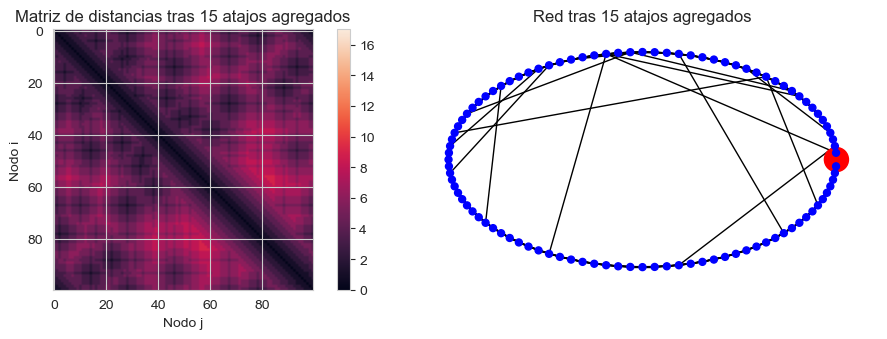

Diametro:  17 --> 9
Distancia media:  8.757575757575758 --> 4.204646464646465
Clustering:  0.6 --> 0.5578730158730159


In [222]:
# Visualizacion del modelo Newman-Watts-Strogatz
n = 100
l = 3
veces = 15

G = Anillo(n, l)
G2 = G.copy()

for k in range(veces):
    agregar_atajo(G2)

MatD0 = np.zeros([n, n])
for i in range(n):
    for j in range(n):
        MatD0[i, j] = nx.shortest_path_length(G, i, j)

MatD = np.zeros([n, n])
for i in range(n):
    for j in range(n):
        MatD[i, j] = nx.shortest_path_length(G2, i, j)

h = .5
tamanos = [300] + (n - 1) * [25]
colores = ['red'] + (n - 1) * ['blue']
dmin = np.min(MatD0)
dmax = np.max(MatD0)

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20*h, 7*h))
pos = ax1.imshow(MatD, vmin=dmin, vmax=dmax)
fig.colorbar(pos, ax=ax1)
ax1.set_title(f'Matriz de distancias tras {veces} atajos agregados')
ax1.set_xlabel('Nodo j')
ax1.set_ylabel('Nodo i')
nx.draw_circular(G2, node_size=tamanos, node_color=colores, ax=ax2)
ax2.set_title(f'Red tras {veces} atajos agregados')
plt.tight_layout()
plt.show()

print('Diametro: ', nx.diameter(G), '-->', nx.diameter(G2))
print('Distancia media: ', nx.average_shortest_path_length(G), '-->', nx.average_shortest_path_length(G2))
print('Clustering: ', nx.average_clustering(G), '-->', nx.average_clustering(G2))



Al agregar atajos sin eliminar las aristas del anillo, el diametro y la distancia promedio disminuyen rapido. El clustering tambien baja, pero suele hacerlo mas lentamente que en el modelo original, porque la estructura local del anillo sigue presente. 

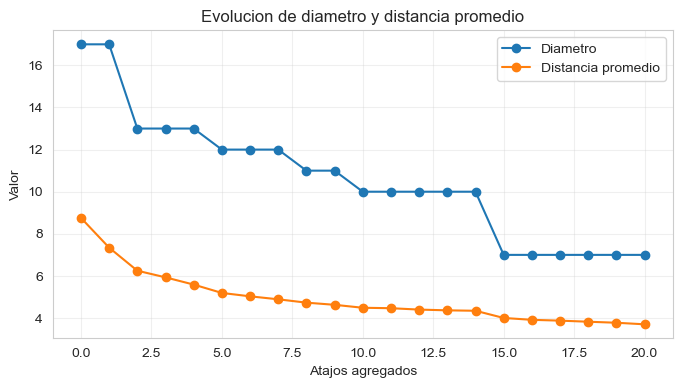

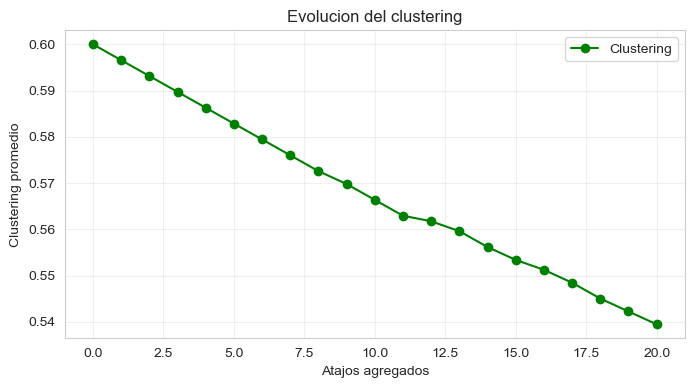

In [223]:
# Evolucion al agregar atajos uno por uno
n = 100
l = 3
k = 20

G = Anillo(n, l)
G2 = G.copy()

Diam = [nx.diameter(G2)]
Dist = [nx.average_shortest_path_length(G2)]
Clus = [nx.average_clustering(G2)]

for i in range(k):
    agregar_atajo(G2)
    Diam.append(nx.diameter(G2))
    Dist.append(nx.average_shortest_path_length(G2))
    Clus.append(nx.average_clustering(G2))

plt.figure(figsize=(8, 4))
plt.plot(Diam, marker='o', label='Diametro')
plt.plot(Dist, marker='o', label='Distancia promedio')
plt.xlabel('Atajos agregados')
plt.ylabel('Valor')
plt.title('Evolucion de diametro y distancia promedio')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(Clus, marker='o', color='green', label='Clustering')
plt.xlabel('Atajos agregados')
plt.ylabel('Clustering promedio')
plt.title('Evolucion del clustering')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


$\textbf{Responde:}$

- Comportamiento de las distancias y el clustering:
	Al agregar atajos, tanto las distancias como el clustering disminuyen, pero las distancias lo hacen mucho mas rapido.
- Forma en que decaen:
	El diametro y la distancia promedio caen de manera marcada en los primeros atajos y luego mas lentamente; el clustering desciende de forma gradual.
- Variable que decae primero:
	La distancia promedio decae primero.
	En una corrida tipica con $n=100$ y $l=3$, despues de 20 atajos el diametro paso de 17 a cerca de 7 u 8, la distancia promedio de 8.76 a cerca de 3.85 y el clustering solo de 0.60 a aproximadamente 0.54.


# Experimento con probabilidad $p$ en el modelo Newman-Watts-Strogatz


En esta variante, cuando $p=0$ obtenemos la red anillo original.

Cuando $p$ aumenta, se agregan atajos, pero no se eliminan las aristas locales. Por eso el grado promedio crece y el clustering suele conservarse mejor que en el modelo original de Watts-Strogatz.

Ademas, cuando $p=1$ no obtenemos una red de Erdos-Renyi: seguimos teniendo el anillo original, mas muchos atajos aleatorios encima.


In [224]:
n = 100
l = 2

E = 100 # La cantidad de redes generadas
p = 0.3

D = []
C = []

for _ in range(E):
    G = Anillo(n, l)
    agregar_atajos(G, p)
    D.append(nx.average_shortest_path_length(G))
    C.append(nx.average_clustering(G))

print(np.mean(D), np.mean(C))


3.399925252525253 0.32890976190476195


Ahora podemos variar el valor de $p$ en un ciclo, generando varias redes para cada valor de $p$. Prueba a cambiar los parametros y observa como cambian $D$ y $C$.


In [225]:
n = 100
l = 2

E = 100 # La cantidad de redes generadas

Dist = []
Clus = []

dominio = [.1, .2, .3]

for p in dominio:
    D = []
    C = []
    for _ in range(E):
        G = Anillo(n, l)
        agregar_atajos(G, p)
        D.append(nx.average_shortest_path_length(G))
        C.append(nx.average_clustering(G))
    Dist.append(np.mean(D))
    Clus.append(np.mean(C))


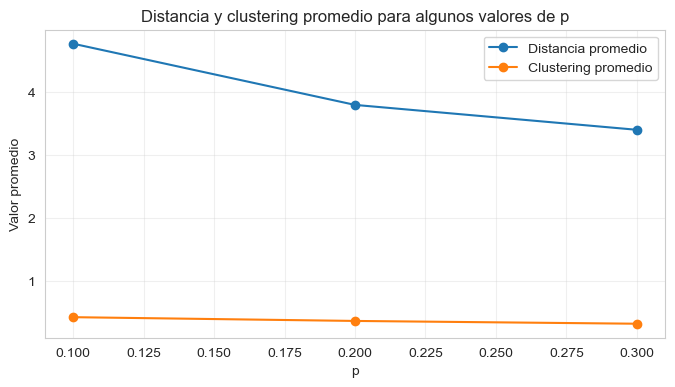

In [226]:
plt.figure(figsize = (8,4))
plt.plot(dominio, Dist, marker='o', label='Distancia promedio')
plt.plot(dominio, Clus, marker='o', label='Clustering promedio')
plt.xlabel('p')
plt.ylabel('Valor promedio')
plt.title('Distancia y clustering promedio para algunos valores de p')
plt.grid(alpha = 0.3)
plt.legend()



Para $p=0.1, 0.2$ y $0.3$, la distancia promedio disminuye con claridad al aumentar $p$.
El clustering queda muy cercano a 0.
Esto sugiere que la variante Newman-Watts conserva mejor la estructura local mientras gana atajos globales.


In [227]:
n = 100
l = 2

E = 100 # La cantidad de redes generadas

Dist = []
Clus = []

dominio = np.arange(.1, .6, .01)

for p in dominio:
    D = []
    C = []
    for _ in range(E):
        G = Anillo(n, l)
        agregar_atajos(G, p)
        D.append(nx.average_shortest_path_length(G))
        C.append(nx.average_clustering(G))
    Dist.append(np.mean(D))
    Clus.append(np.mean(C))


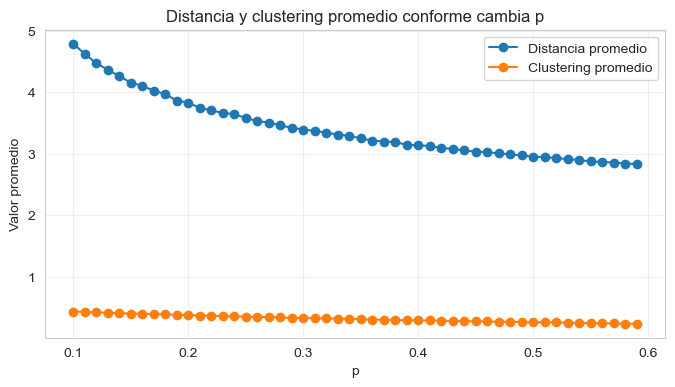

In [228]:
plt.figure(figsize = (8,4))
plt.plot(dominio, Dist, 'o-', label='Distancia promedio')
plt.plot(dominio, Clus, 'o-', label='Clustering promedio')
plt.xlabel('p')
plt.ylabel('Valor promedio')
plt.title('Distancia y clustering promedio conforme cambia p')
plt.grid(alpha = 0.3)
plt.legend()



Cuando $p$ recorre valores entre $0.1$ y $0.6$, la distancia promedio sigue disminuyendo, mientras que el clustering decae mas lento que en el modelo original.
La red se vuelve eficiente globalmente, pero su estructura local tarda mas en deteriorarse.


In [229]:
n = 100
l = 2
G = Anillo(n, l)
D0 = nx.average_shortest_path_length(G)
C0 = nx.average_clustering(G)

E = 30 # La cantidad de redes generadas

Dist = []
Clus = []

dominio = np.arange(.01, .6, .01)

for p in dominio:
    D = []
    C = []
    for _ in range(E):
        G = Anillo(n, l)
        agregar_atajos(G, p)
        D.append(nx.average_shortest_path_length(G))
        C.append(nx.average_clustering(G))
    Dist.append(np.mean(D)/D0)
    Clus.append(np.mean(C)/C0)


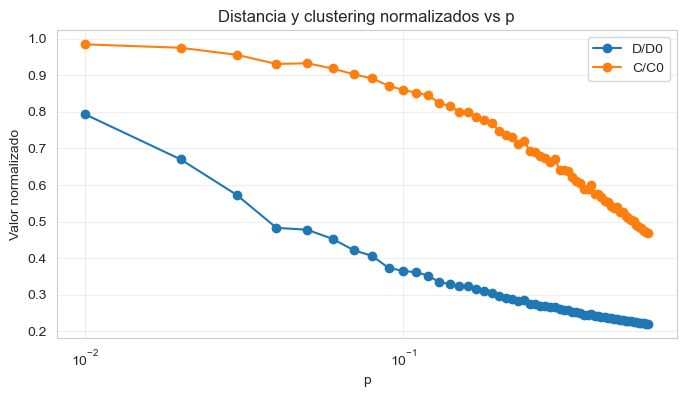

In [230]:
plt.figure(figsize = (8,4))
plt.plot(dominio, Dist, 'o-', label='D/D0')
plt.plot(dominio, Clus, 'o-', label='C/C0')
plt.xscale('log')
plt.xlabel('p')
plt.ylabel('Valor normalizado')
plt.title('Distancia y clustering normalizados vs p')
plt.grid(alpha = 0.3)
plt.legend()



En escala logaritmica se ve que $D/D_0$ cae antes que $C/C_0$.
Eso significa que aparecen caminos cortos muy pronto, mientras el clustering todavia conserva una fraccion grande de su valor inicial.


Vamos a tomar valores de $p$ usando la funcion `np.logspace` para identificar mejor la region de mundo pequeno. Tambien puedes comparar con la funcion de NetworkX `newman_watts_strogatz_graph`.


In [231]:
n = 100
l = 2
G = Anillo(n, l)
D0 = nx.average_shortest_path_length(G)
C0 = nx.average_clustering(G)

E = 30 # La cantidad de redes generadas

Dist = []
Clus = []

dominio = np.logspace(-4, 0, 20)

for p in dominio:
    D = []
    C = []
    for _ in range(E):
        G = Anillo(n, l)
        agregar_atajos(G, p)
        D.append(nx.average_shortest_path_length(G))
        C.append(nx.average_clustering(G))
    Dist.append(np.mean(D)/D0)
    Clus.append(np.mean(C)/C0)


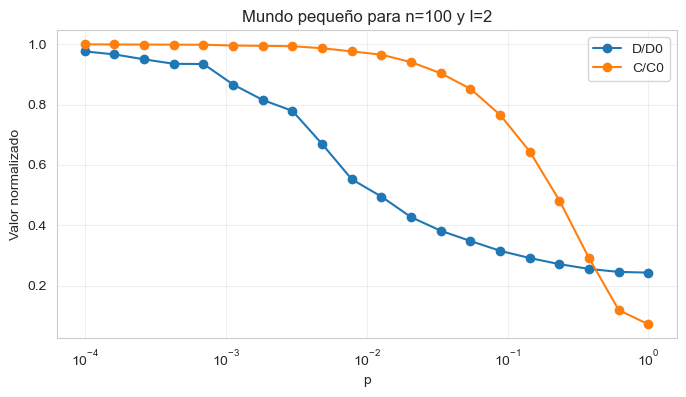

In [243]:
plt.figure(figsize = (8,4))
plt.plot(dominio, Dist, 'o-', label='D/D0')
plt.plot(dominio, Clus, 'o-', label='C/C0')
plt.xscale('log')
plt.xlabel('p')
plt.ylabel('Valor normalizado')
plt.title('Mundo pequeño para n=100 y l=2')
plt.grid(alpha = 0.3)
plt.legend()



Aqui se observa con mas claridad el regimen mundo pequeno.
Para valores pequenos de $p$, la distancia normalizada ya bajo mucho, pero el clustering normalizado sigue cerca de $1$.

Prueba ahora a cambiar la cantidad de nodos a valores de $n$ mas grandes.


In [233]:
n = 200
l = 5
G = Anillo(n, l)
D0 = nx.average_shortest_path_length(G)
C0 = nx.average_clustering(G)

E = 20 # La cantidad de redes generadas

Dist = []
Clus = []

dominio = np.logspace(-4, 0, 20)

for p in dominio:
    D = []
    C = []
    for _ in range(E):
        G = Anillo(n, l)
        agregar_atajos(G, p)
        D.append(nx.average_shortest_path_length(G))
        C.append(nx.average_clustering(G))
    Dist.append(np.mean(D)/D0)
    Clus.append(np.mean(C)/C0)


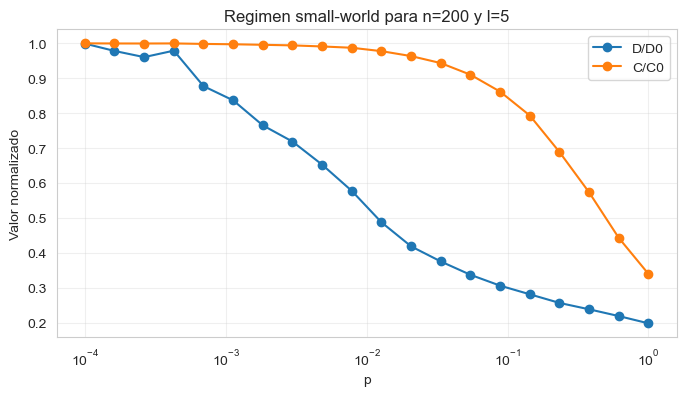

In [234]:
plt.figure(figsize = (8,4))
plt.plot(dominio, Dist, 'o-', label='D/D0')
plt.plot(dominio, Clus, 'o-', label='C/C0')
plt.xscale('log')
plt.xlabel('p')
plt.ylabel('Valor normalizado')
plt.title('Regimen small-world para n=200 y l=5')
plt.grid(alpha = 0.3)
plt.legend()



Con valores pequenos de $p$ aparecen pocos atajos, pero eso ya alcanza para reducir bastante la distancia promedio mientras el clustering sigue alto.
Con valores grandes de $p$ la red gana muchos atajos, la distancia promedio se hace muy pequena y el clustering empieza a bajar de manera mas visible, aunque suele mantenerse mas alto que en el modelo original.
Eso ocurre porque en Newman-Watts no se eliminan las aristas locales: la red conserva su base regular y encima agrega conexiones largas.
Un intervalo razonable donde se observan ambas propiedades es $p \approx 0.02$ a $0.2$ para $n=100$ y $l=2$.
Si se usan mas nodos, el intervalo puede empezar un poco antes; por ejemplo, con $n=200$ y $l=5$ aparecio aproximadamente desde $p \approx 0.005$ hasta cerca de $0.14$.


# Experimentos con el modelo original de Watts-Strogatz


Ahora repetimos el experimento usando `re_enlazar_ws`, es decir, el modelo original de Watts-Strogatz.

En este caso las aristas locales pueden desaparecer al re-enlazar, asi que esperamos que el clustering baje mas rapido que en Newman-Watts-Strogatz.


In [235]:
n = 100
l = 2

E = 100 # La cantidad de redes generadas

Dist = []
Clus = []

dominio = [.1, .2, .3]

for p in dominio:
    D = []
    C = []
    while len(D) < E:
        G = Anillo(n, l)
        re_enlazar_ws(G, p)
        if not nx.is_connected(G):
            continue
        D.append(nx.average_shortest_path_length(G))
        C.append(nx.average_clustering(G))
    Dist.append(np.mean(D))
    Clus.append(np.mean(C))


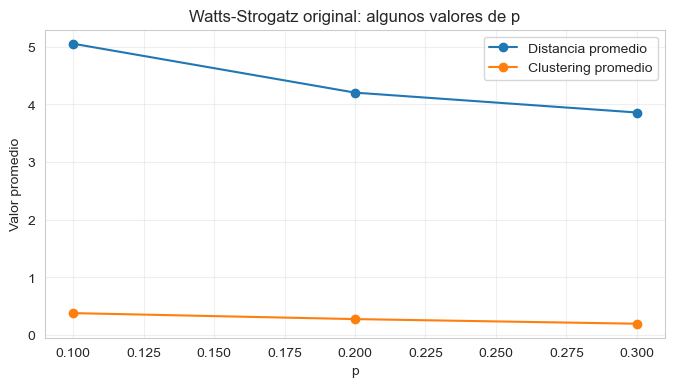

In [236]:
plt.figure(figsize = (8,4))
plt.plot(dominio, Dist, marker='o', label='Distancia promedio')
plt.plot(dominio, Clus, marker='o', label='Clustering promedio')
plt.xlabel('p')
plt.ylabel('Valor promedio')
plt.title('Watts-Strogatz original: algunos valores de p')
plt.grid(alpha = 0.3)
plt.legend()



Para $p=0.1, 0.2$ y $0.3$, la distancia promedio disminuye conforme aumenta $p$.
El clustering tambien disminuye, pero aqui suele caer mas que en Newman-Watts, porque el re-enlace elimina parte de la estructura local original.
Esto muestra una diferencia importante entre ambos modelos: en Watts-Strogatz original se ganan atajos, pero a costa de perder enlaces locales.


In [237]:
n = 100
l = 2
G = Anillo(n, l)
D0 = nx.average_shortest_path_length(G)
C0 = nx.average_clustering(G)

E = 30 # La cantidad de redes generadas

Dist = []
Clus = []

dominio = np.logspace(-4, 0, 20)

for p in dominio:
    D = []
    C = []
    intentos = 0
    while len(D) < E and intentos < 10000:
        intentos += 1
        G = Anillo(n, l)
        re_enlazar_ws(G, p)
        if not nx.is_connected(G):
            continue
        D.append(nx.average_shortest_path_length(G))
        C.append(nx.average_clustering(G))
    Dist.append(np.mean(D)/D0)
    Clus.append(np.mean(C)/C0)


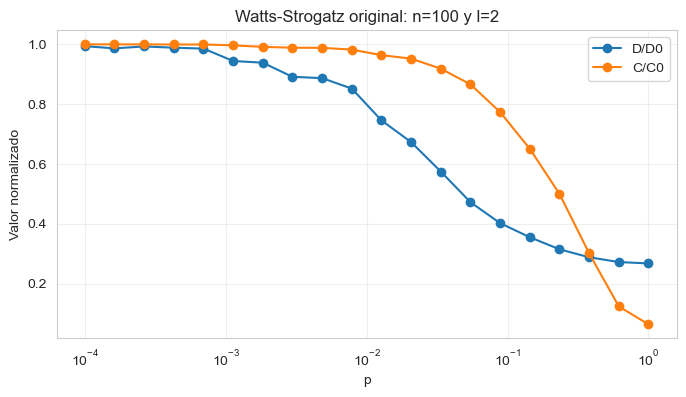

In [238]:
plt.figure(figsize = (8,4))
plt.plot(dominio, Dist, 'o-', label='D/D0')
plt.plot(dominio, Clus, 'o-', label='C/C0')
plt.xscale('log')
plt.xlabel('p')
plt.ylabel('Valor normalizado')
plt.title('Watts-Strogatz original: n=100 y l=2')
plt.grid(alpha = 0.3)
plt.legend()



La distancia normalizada cae antes que el clustering, asi que tambien aparece una region de mundo pequeno.
Sin embargo, la caida del clustering es mas rapida que en Newman-Watts, porque aqui si se reubican aristas del anillo.
Por eso la zona donde coexisten caminos cortos y clustering alto es mas estrecha.


In [239]:
n = 200
l = 5
G = Anillo(n, l)
D0 = nx.average_shortest_path_length(G)
C0 = nx.average_clustering(G)

E = 20 # La cantidad de redes generadas

Dist = []
Clus = []

dominio = np.logspace(-4, 0, 20)

for p in dominio:
    D = []
    C = []
    intentos = 0
    while len(D) < E and intentos < 10000:
        intentos += 1
        G = Anillo(n, l)
        re_enlazar_ws(G, p)
        if not nx.is_connected(G):
            continue
        D.append(nx.average_shortest_path_length(G))
        C.append(nx.average_clustering(G))
    Dist.append(np.mean(D)/D0)
    Clus.append(np.mean(C)/C0)


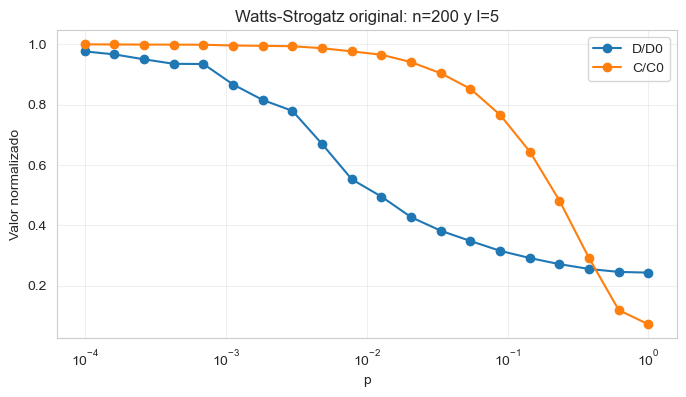

In [240]:
plt.figure(figsize = (8,4))
plt.plot(dominio, Dist, 'o-', label='D/D0')
plt.plot(dominio, Clus, 'o-', label='C/C0')
plt.xscale('log')
plt.xlabel('p')
plt.ylabel('Valor normalizado')
plt.title('Watts-Strogatz original: n=200 y l=5')
plt.grid(alpha = 0.3)
plt.legend()



Con valores pequenos de $p$ aparecen pocos atajos, y eso ya reduce mucho la distancia promedio mientras el clustering sigue relativamente alto.
Con valores grandes de $p$ la red se vuelve mucho mas aleatoria: la distancia promedio es muy pequena, pero el clustering cae de forma marcada.
A diferencia de Newman-Watts, aqui el clustering baja mas rapido porque el modelo reubica aristas y rompe parte de la estructura local original.
Un intervalo razonable donde se observan ambas propiedades es $p \approx 0.02$ a $0.09$ para $n=100$ y $l=2$.
Si se usan mas nodos, el intervalo puede empezar un poco antes; por ejemplo, con $n=200$ y $l=5$ aparecio aproximadamente desde $p \approx 0.005$ hasta cerca de $0.09$.
